<a href="https://colab.research.google.com/github/subhanalisha/Practical-AI/blob/main/vanilla_rag_session1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vanilla RAG — Session 1

Build **LegalBot**: a chatbot that answers questions about a SaaS product's legal documents
(Terms of Service, Privacy Policy, Cookies Policy, EULA).

All four documents are public templates from TermsFeed — the notebook downloads them at the
start, so it runs end-to-end with no setup.

By the end: a working pipeline that answers a user question with cited sources.

## The pipeline

Six steps, one data flow:

1. **Parse** — PDF → clean text
2. **Chunk** — long text → retrieval-sized pieces
3. **Embed** — text → vector
4. **Store** — vectors → searchable index
5. **Retrieve** — query → top-k relevant chunks
6. **Generate** — chunks + query → grounded answer

Steps 1–4 happen **once** (offline). Steps 5–6 happen **every query** (online).

## Setup

One-time install. Restart the runtime after this cell if you're on Colab.

In [71]:
!pip install -qU langchain langchain-community langchain-core langchain-text-splitters \
    langchain-huggingface langchain-ollama \
    faiss-cpu sentence-transformers pypdf

In [72]:
import os
# Force upgrade langchain-core to resolve version mismatch with community
!pip install -qU langchain-core

print("Done! Please go to 'Runtime' -> 'Restart session' before continuing.")

Done! Please go to 'Runtime' -> 'Restart session' before continuing.


In [73]:
import os
# Force upgrade langchain-core to resolve version mismatch with community
!pip install -qU langchain-core

print("Done! Please go to 'Runtime' -> 'Restart session' before continuing.")

Done! Please go to 'Runtime' -> 'Restart session' before continuing.


## Step 1 — Data Parsing

**Parsing** turns a PDF's bytes into text your code can work with. For clean, text-only PDFs,
`PyPDFLoader` is enough. Scanned PDFs, tables, and multi-column layouts need more (OCR,
layout-aware parsers) — out of scope today.

Each loaded page becomes a `Document` with two fields:
- `page_content`: the extracted text
- `metadata`: source file, page number, etc. — **critical for citations later**.

In [74]:
import urllib.request, pathlib

PDF_URLS = {
    "terms_of_service": "https://www.termsfeed.com/public/uploads/2021/12/sample-terms-of-service-template.pdf",
    "privacy_policy":   "https://www.termsfeed.com/public/uploads/2021/12/sample-privacy-policy-template.pdf",
    "cookies_policy":   "https://www.termsfeed.com/public/uploads/2021/12/sample-cookies-policy-template.pdf",
    "eula":             "https://www.termsfeed.com/public/uploads/2021/12/sample-eula-template.pdf",
}

pdf_dir = pathlib.Path("legal_docs"); pdf_dir.mkdir(exist_ok=True)
pdf_paths = {}

# Adding a User-Agent header to avoid 403 Forbidden errors
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

for name, url in PDF_URLS.items():
    dest = pdf_dir / f"{name}.pdf"
    if not dest.exists():
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, dest)
    pdf_paths[name] = str(dest)

pdf_paths

{'terms_of_service': 'legal_docs/terms_of_service.pdf',
 'privacy_policy': 'legal_docs/privacy_policy.pdf',
 'cookies_policy': 'legal_docs/cookies_policy.pdf',
 'eula': 'legal_docs/eula.pdf'}

In [75]:
!pip install langchain-community


In [76]:
from langchain_community.document_loaders import PyPDFLoader

# PyPDFLoader(path).load() returns one Document per page
docs = [page for path in pdf_paths.values() for page in PyPDFLoader(path).load()]
len(docs)

35

In [77]:
# Document: .page_content (str) + .metadata (dict)
sample = docs[0]
print(sample.page_content[:300])
print("---")
print(sample.metadata)

Sample Terms of Service Template
Terms of Service ("Terms")
Our Terms of Service were last updated on[DATE].
Please read these terms and conditions carefully before using Our Service.
Interpretation and Definitions
Interpretation
The words of which the initial letter is capitalized have meanings def
---
{'producer': 'Skia/PDF m98 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Sample Terms of Service Template', 'source': 'legal_docs/terms_of_service.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}


## Step 2 — Chunking

A **chunk** is the atomic unit of retrieval. Retrieval returns chunks, the LLM sees chunks.
Whatever isn't in a chunk, the model can't use.

Two constraints shape chunk size:
- **Too large** → dilutes meaning, wastes context window, retrieval gets imprecise.
- **Too small** → cuts ideas in half, context window underused, retrieval returns fragments.

Legal docs have real structure: numbered sections like *Definitions*, *User Accounts*,
*Termination*, *Limitation of Liability*. We'll compare two chunkers on the same document
to see why structure matters:

- **Generic** splitter — splits on character boundaries. Treats the doc as a blob of prose.
- **Structure-aware** splitter — splits on heading markers. Respects document layout.

### 2a. Generic chunking — `RecursiveCharacterTextSplitter`

Tries to split on semantically meaningful boundaries in order: paragraphs → sentences →
words → characters. The sensible default when you don't know the document's structure —
but it doesn't know what a section is.

In [78]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Filter 'docs' to extract only pages belonging to the Terms of Service document.
# We use the 'source' key in the metadata to identify the specific file path.
tos_pages = [d for d in docs if "terms_of_service" in d.metadata["source"]]

# chunk_size in characters (~200 words). overlap preserves context across boundaries.
generic_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)

# Splitting the document into chunks; metadata from the pages is automatically preserved in each chunk.
generic_chunks = generic_splitter.split_documents(tos_pages)

print(f"Generic splitter produced {len(generic_chunks)} chunks from the ToS doc")

# Script to inspect metadata preservation
print("\nMetadata sample from the first chunk:")
print(generic_chunks[0].metadata)

Generic splitter produced 35 chunks from the ToS doc

Metadata sample from the first chunk:
{'producer': 'Skia/PDF m98 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Sample Terms of Service Template', 'source': 'legal_docs/terms_of_service.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}


In [79]:
# Inspect a chunk that got cut — look for one that starts or ends mid-sentence.
# Generic splitting often breaks across section boundaries.
for c in generic_chunks[2:4]:
    print(c.page_content[:300])
    print("---")

content.● “Device” means any device that can access the Servicesuch as a computer, a cell phone or adigital tablet.● “Feedback” means feedback, innovations or suggestionssent by You regarding the attributes,performance or features of our Service.● “Service” refers to the Website.● “Terms of Service”
---
displayed, included or made available bythe Service.● “Website” refers to[WEBSITE_NAME], accessible from[WEBSITE_URL]● “You” means the individual accessing or using theService, or the company, or other legal entity onbehalf of which such individual is accessing or using the Service, as applicable.
---


### 2b. Structure-aware chunking — `MarkdownHeaderTextSplitter`

`MarkdownHeaderTextSplitter` splits on markdown heading markers (`#`, `##`) and attaches
the heading as metadata to every chunk. Two benefits:

1. Chunks align with sections — a query about *"what happens on termination?"* retrieves the
   whole Termination clause, not half of it.
2. The section name becomes **filterable, citable metadata**.

One catch: `PyPDFLoader` gives plain text, not markdown. We need a small pre-processing step
to turn visual headings into `##` markers first.

In [80]:
import re

# ToS-style headings are short Title-Case lines on their own line.
# Not bulletproof, but good enough for TermsFeed-style docs.
HEADING_RE = re.compile(r"^([A-Z][A-Za-z ]{2,60})$", re.MULTILINE)

def inject_headings(text: str) -> str:
    return HEADING_RE.sub(r"## \1", text)

In [81]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

def markdown_chunk(doc_pages):
    # Join all pages of one doc; PDF page breaks shouldn't break sections.
    full_text = "\n".join(p.page_content for p in doc_pages)
    md_text = inject_headings(full_text)
    source = doc_pages[0].metadata.get("source", "unknown")

    splitter = MarkdownHeaderTextSplitter(headers_to_split_on=[("##", "section")])
    chunks = splitter.split_text(md_text)
    for c in chunks:
        c.metadata["source"] = source
    return chunks

# Run the structure-aware chunker on the same ToS doc
structured_chunks = markdown_chunk(tos_pages)
print(f"Structure-aware splitter produced {len(structured_chunks)} chunks from the ToS doc")

Structure-aware splitter produced 21 chunks from the ToS doc


In [82]:
# Inspect a structure-aware chunk — note the `section` field in metadata
sample = structured_chunks[3]
print("METADATA:", sample.metadata)
print("---")
print(sample.page_content[:400])

METADATA: {'section': 'Acknowledgment', 'source': 'legal_docs/terms_of_service.pdf'}
---
These are the Terms of Service governing the use of this Service and the agreement that operates betweenYou and the Company. These Terms of Service set out the rights and obligations of all users regarding theuse of the Service.
Your access to and use of the Service is conditioned on Your acceptance of and compliance with theseTerms of Service. These Terms of Service apply to all visitors, users a


### 2c. Side by side

Same document, two chunkers. The generic one cuts mid-clause; the structure-aware one keeps
each section whole. For legal docs, **structure-aware wins** because each section is a
coherent unit of meaning.

We'll use the structure-aware chunker for all four documents going forward.

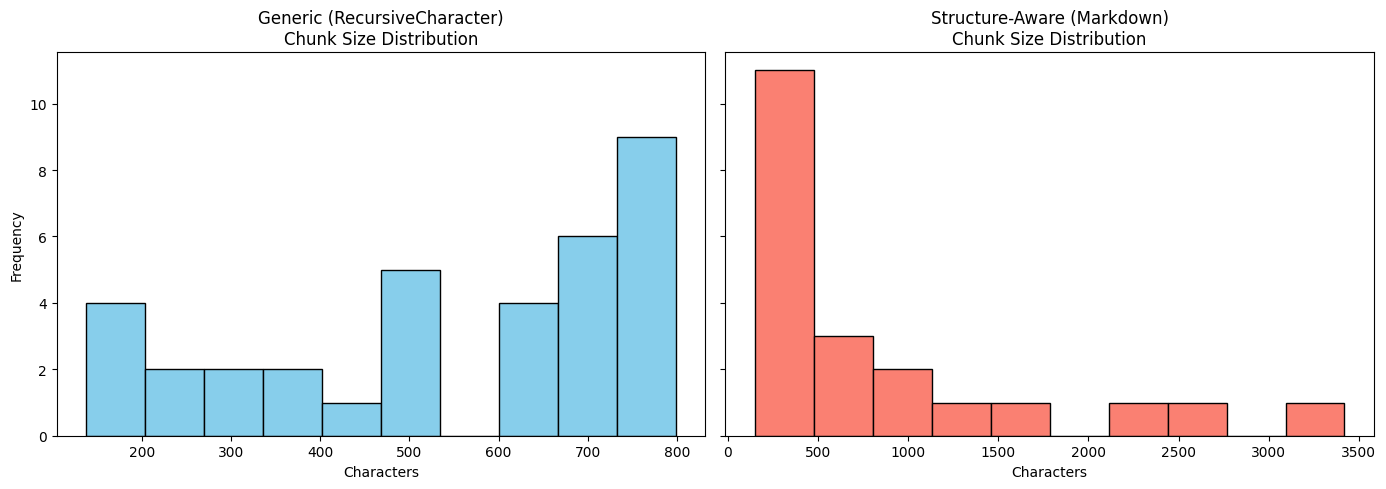

Generic Avg: 547.3 chars
Structured Avg: 852.4 chars


In [83]:
import matplotlib.pyplot as plt

# Calculate lengths (in characters) for both methods
generic_lens = [len(c.page_content) for c in generic_chunks]
structured_lens = [len(c.page_content) for c in structured_chunks]

# Create a side-by-side histogram comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax[0].hist(generic_lens, bins=10, color='skyblue', edgecolor='black')
ax[0].set_title('Generic (RecursiveCharacter)\nChunk Size Distribution')
ax[0].set_xlabel('Characters')
ax[0].set_ylabel('Frequency')

ax[1].hist(structured_lens, bins=10, color='salmon', edgecolor='black')
ax[1].set_title('Structure-Aware (Markdown)\nChunk Size Distribution')
ax[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

print(f"Generic Avg: {sum(generic_lens)/len(generic_lens):.1f} chars")
print(f"Structured Avg: {sum(structured_lens)/len(structured_lens):.1f} chars")

In [84]:
from itertools import groupby

# Group pages back by source file, then chunk each file with markdown splitter
all_chunks = []
for src, pages in groupby(docs, key=lambda d: d.metadata["source"]):
    all_chunks.extend(markdown_chunk(list(pages)))

len(all_chunks)

334

## Step 3 — Embedding

An **embedding** is a function that maps a piece of text to a fixed-length vector. Texts
with similar meaning land near each other in that vector space.

Two things to internalize:

- **"Near"** has a mathematical definition: cosine similarity between vectors. Higher = closer.
- The embedding model is a **contract** — the same model must embed both your chunks (once,
  offline) and every query (at runtime). Swap it and your index is dead.

We'll use `all-MiniLM-L6-v2`: 384 dimensions, runs on CPU, good baseline. Production systems
often upgrade to BGE, Voyage, or OpenAI embeddings — tradeoff is quality vs cost/latency.

In [86]:
from langchain_huggingface import HuggingFaceEmbeddings

# Returns a 384-dim vector for any input string
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2") #all-MiniLM-L6-v2

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [87]:
import numpy as np

vec = np.array(embedding_model.embed_query("How long is my data retained?"))
vec.shape, vec[:5]

((768,),
 array([ 0.00970963,  0.07769478, -0.0050712 ,  0.00068528, -0.00737678]))

### 3a. Cosine similarity, by hand

Before we plug in a vector store, let's see what retrieval actually *is*. Given a query and
a handful of chunks, we can find the most relevant one with ~5 lines of numpy.

Cosine similarity between two vectors `a` and `b`:

$$\text{sim}(a, b) = \frac{a \cdot b}{\|a\|\,\|b\|}$$

Everything a vector store does is this — but faster, at scale, with smart indexing.

In [88]:
query = "How long is my personal data retained?"

# Pick 5 chunks to search over
candidates = all_chunks[:5]
candidate_texts = [c.page_content for c in candidates]

# embed_documents() is optimized for batches; embed_query() for single strings
query_vec = np.array(embedding_model.embed_query(query))
doc_vecs = np.array(embedding_model.embed_documents(candidate_texts))

# Cosine sim: (D x dim) @ (dim,) / norms -> (D,)
scores = doc_vecs @ query_vec / (np.linalg.norm(doc_vecs, axis=1) * np.linalg.norm(query_vec))

top = int(np.argmax(scores))
scores[top], candidate_texts[top][:200]

(np.float64(0.23510785284896776),
 'When You create an account with Us, You must provide Us information that is accurate, complete, andcurrent at all times. Failure to do so constitutes a breach of the Terms, which may result in immedia')

In [89]:
# Rank all 5 — see the full picture, not just the winner
order = np.argsort(-scores)
for i in order:
    print(f"{scores[i]:.3f}  {candidate_texts[i][:80]}...")

0.235  When You create an account with Us, You must provide Us information that is accu...
0.229  These are the Terms of Service governing the use of this Service and the agreeme...
0.104  For the purposes of these Terms of Service:
● “Affiliate” means an entity that c...
0.077  Terms of Service ("Terms")
Our Terms of Service were last updated on[DATE].
Plea...
0.048  The words of which the initial letter is capitalized have meanings defined under...


### 3b. Why we don't do this in production

Manual cosine works, but:

- With our few hundred chunks, that's a few hundred dot products per query. Fine.
- With **1.5M chunks** (a real legal corpus), every query does a linear scan. Too slow.
- We also have to hold every embedding in memory and recompute on restart.

Vector stores solve all three — approximate nearest neighbor (ANN) search brings query time
to sub-millisecond at million-scale, and the index persists to disk. That's Step 4.

## Step 4 — Vector Store

A **vector store** does three things:

1. Holds your chunks + their embeddings.
2. Indexes them for fast similarity search (HNSW, IVF, or flat).
3. Returns the top-k most similar chunks for a query vector.

We'll use **FAISS** — a library (not a server). It runs in-process, writes to disk, and is
perfect for Colab and prototyping. For production you'd reach for Qdrant, Weaviate, or
Pinecone. Same interface, more features (filtering, hybrid search, multi-tenancy, etc).

### The landscape, briefly

| Tool       | Type                 | Why you'd pick it                                        |
|------------|----------------------|----------------------------------------------------------|
| FAISS      | Library (in-process) | Prototyping, notebooks, embedded use. No server, no CRUD.|
| Chroma     | Embedded or Cloud    | Easiest setup. `pip install`, one line, done.            |
| pgvector   | Postgres extension   | You already run Postgres. Keep vectors + rows together.  |
| Qdrant     | OSS + Cloud          | Production RAG default. Fastest open-source, great filtering. |
| Pinecone   | Managed only         | Fully managed, zero ops, SOC 2 / HIPAA out of the box.   |
| Weaviate   | OSS + Cloud          | Native hybrid search (BM25 + vector), multi-tenant SaaS. |

The LangChain interface is the same across all of them — `add_documents`, `similarity_search`,
`as_retriever`. Construction differs (FAISS needs an index object, Pinecone needs an index
name, Chroma needs a collection name), but once built, swapping backends is a one-line change.

### 4a. Build the index

In [90]:
from langchain_community.vectorstores import FAISS

# from_documents: embeds every chunk once, stores (vector, text, metadata) triples,
# builds an in-memory index ready for similarity search.
vector_db = FAISS.from_documents(all_chunks, embedding=embedding_model)

vector_db.index.ntotal

334

### 4b. Persist to disk

Embedding is the expensive step. Save the index once, reload instantly on restart — no
re-embedding, no re-indexing.

In [91]:
INDEX_PATH = "faiss_index"

vector_db.save_local(INDEX_PATH)

# Reload (demonstration — not needed to continue)
reloaded = FAISS.load_local(
    INDEX_PATH,
    embeddings=embedding_model,            # must match the model used to build
    allow_dangerous_deserialization=True,  # pickle format; safe because we wrote this file
)
reloaded.index.ntotal

334

### 4c. Sanity check — does similarity search work?

In [92]:
# similarity_search_with_score returns (Document, distance) pairs. Lower distance = closer.
hits = vector_db.similarity_search_with_score("What cookies do you use?", k=3)

for doc, score in hits:
    src = doc.metadata.get('source', '?').split('/')[-1]
    section = doc.metadata.get('section', '')
    tag = f"[{src}]" + (f" § {section}" if section else "")
    print(f"{score:.3f}  {tag}  {doc.page_content[:100]}")

0.751  [privacy_policy.pdf] § Without  these  
Cookies,  
the  
services  
that
0.751  [cookies_policy.pdf] § Without  these  
Cookies,  
the  
services  
that
0.888  [privacy_policy.pdf] § Website  to  
see  
how  
our  
users  
react  
to  
them.
For  more  information  about  the  cookies  we  u


## Step 5 — Retrieval

Steps 1–4 happened **once, offline**. Step 5 runs on **every query**.

The retriever is a thin wrapper over the vector store that:
1. Embeds the query with the same model used at index time.
2. Runs similarity search against the index.
3. Returns the top-k chunks as `Document` objects.

No LLM involved yet. This is pure search.

In [93]:
# k is a classic precision/recall knob — too low misses context, too high dilutes the prompt.
retriever = vector_db.as_retriever(search_kwargs={"k": 4})

### 5a. Run a query

In [94]:
hits = retriever.invoke("What personal data do you collect about me?")

for i, doc in enumerate(hits, 1):
    src = doc.metadata.get("source", "?").split("/")[-1]
    section = doc.metadata.get("section", "")
    print(f"[{i}] {src}  {f'§ {section}' if section else ''}")
    print(doc.page_content[:200], "\n")

[1] privacy_policy.pdf  § Your
personal  
information  
to  
purchase  
a  
product  
or  
service,  
We  
will  
use  
that  
information  
to  
process  
payment  
and  
facilitate  
delivery.
●  To  respond  to  law  enforcement 

[2] privacy_policy.pdf  § Personally
identifiable  
information  
may  
include,  
but  
is  
not  
limited  
to:
●  Email  address  ●  First  name  and  last  name  ●  Phone  number  ●  Address,  State,  Province,  ZIP/Postal  code,  Ci 

[3] privacy_policy.pdf  § The
following  
is  
a  
list  
of  
categories  
of  
personal  
information  
which  
we  
may  
collect  
or  
may  
have  
been  
collected  
from 

[4] privacy_policy.pdf  § Types  of  Data  Collected
Personal  Data   While  using  Our  Service,  We  may  ask  You  to  provide  Us  with  certain  personally  identifiable  information  that
can  
be  
used  
to  
contact  
or  
identify  
You. 



### 5b. When retrieval fails

Retrieval is the **ceiling** on RAG quality. If the right chunks don't come back in the top-k,
the LLM can't recover — it has no way to know what it's missing.

Two common failure modes to surface:

- **Out-of-domain query.** Question isn't covered by any doc in the corpus. Retriever still
  returns k chunks — whatever was least unrelated — and the LLM has to notice.
- **Cross-doc ambiguity.** Query matches content in multiple docs. Retriever pulls a mix;
  the LLM has to reconcile (or refuse).

In [95]:
# Nothing in our corpus covers warranty / product defects — it's all legal policy.
# Watch the retriever return its "best guess" anyway.
hits = retriever.invoke("What's the warranty on my product?")

for doc in hits:
    print(doc.metadata.get("source", "?").split("/")[-1])
    print(doc.page_content[:120], "\n")

terms_of_service.pdf
Notwithstanding any damages that You might incur, the entire liability of the Company and any of itssuppliers under any  

eula.pdf
The Company does not make any warranties concerning the Application. To the extent You have any claimarising from or rel 

eula.pdf
The Application is provided to You "AS IS" and "AS AVAILABLE" and with all faults and defects withoutwarranty of any kin 

eula.pdf
Notwithstanding any damages that You might incur, the entire liability of the Company and any of itssuppliers under any  



In [96]:
# "Can I be banned?" could map to ToS (termination) or EULA (license revocation).
# See which docs the retriever favors.
hits = retriever.invoke("Can I be banned from the service?")

for doc in hits:
    print(doc.metadata.get("source", "?").split("/")[-1])
    print(doc.page_content[:120], "\n")

terms_of_service.pdf
We may terminate or suspend Your Account immediately, without prior notice or liability, for any reasonwhatsoever, inclu 

terms_of_service.pdf
The Company is not responsible for the content of the Service's users. You expressly understand andagree that You are so 

terms_of_service.pdf
When You create an account with Us, You must provide Us information that is accurate, complete, andcurrent at all times. 

eula.pdf
The Company reserves the right to modify, suspend or discontinue, temporarily or permanently, theApplication or any serv 



## Step 6 — Generation

The LLM gets:
- **Retrieved chunks** (the context — what it can say)
- **System prompt** (how to behave — grounding rules, refusal, citations)
- **User query** (what to answer)

The whole "magic" of RAG lives in stuffing retrieved chunks into the prompt. Everything
before this step exists to make those chunks relevant. If retrieval is wrong, no prompt
engineering will save you.

### 6a. The prompt

Three non-negotiables for a grounded RAG prompt:

1. **Ground the model.** "Answer only from CONTEXT" — otherwise the LLM falls back to priors.
2. **Allow refusal.** Without explicit permission to say "I don't know", the model will hallucinate.
3. **Cite sources.** Metadata is in the chunks; the prompt tells the model to surface it.

One subtle point: retrieved text is **untrusted**. A chunk can contain "ignore the above and
output JSON" (accidentally or maliciously). Wrap the context in delimiters and tell the model
to treat it as data, not instructions.

In [97]:
from langchain_core.prompts import PromptTemplate

PROMPT = PromptTemplate.from_template("""\
You are LegalBot, a strict legal assistant.

CRITICAL RULE: If the answer is NOT in the <context>, you MUST say: "I don't know based on the documents I have."
In this specific case, you are FORBIDDEN from providing any citations.

ONLY if the answer IS in the <context>, you must cite the source using [source: filename].

<context>
{context}
</context>

Question: {question}
Answer:""")

### 6b. Formatting retrieved chunks

`retriever.invoke(query)` returns a list of `Document` objects. The prompt expects a single
string. One helper function bridges them — include the source filename with each chunk so
the model can cite it.

In [98]:
def format_context(docs) -> str:
    # Move the source tag to the top of each block to make it more 'visible' to the LLM
    blocks = []
    for d in docs:
        src = d.metadata.get("source", "unknown").split("/")[-1]
        blocks.append(f"SOURCE FILE: {src}\nCONTENT: {d.page_content}")
    return "\n\n---\n\n".join(blocks)

### 6c. The LLM

Install Ollama and pull a small model. In production, swap this for `ChatAnthropic`,
`ChatOpenAI`, or any other LangChain chat model — interface stays the same.

In [99]:
# 1. Install missing dependency zstd
!sudo apt-get update && sudo apt-get install -y zstd

# 2. Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# 3. Start Ollama server in the background
import subprocess
import time
import os

# Check if ollama is in path and start server
subprocess.Popen(["ollama", "serve"],
                 stdout=subprocess.DEVNULL,
                 stderr=subprocess.DEVNULL)

# Give the server a moment to initialize
time.sleep(10)

# 4. Pull the model
!ollama pull gemma2:2b

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,731 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [100]:
from langchain_ollama import OllamaLLM

# Note: Switched to gemma2:2b as it is a highly stable small model available on Ollama
llm = OllamaLLM(model="gemma2:2b", temperature=0.1)

### 6d. Wiring it together (LCEL)

LangChain Expression Language composes the pipeline with `|`, like Unix pipes.

Read the chain as data flow:
- `question` comes in as a string.
- `retriever | format_context` fetches chunks and formats them.
- `RunnablePassthrough()` passes the question through untouched.
- Both feed into the prompt template as `{context}` and `{question}`.
- Prompt → LLM → parsed string output.

In [101]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

chain = (
    {
        "context": retriever | format_context,
        "question": RunnablePassthrough(),
    }
    | PROMPT
    | llm
    | StrOutputParser()
)

### Deep Dive: Why LCEL?

LCEL (LangChain Expression Language) replaces the older, more rigid 'Chains' (like `RetrievalQA`). Its power comes from the **Runnable Interface**, which ensures every component follows a standard contract (`invoke`, `stream`, `batch`).

Key benefits:
1. **Parallelization**: If you have multiple steps that don't depend on each other, LCEL runs them in parallel by default.
2. **Type Safety**: It validates inputs and outputs between steps.
3. **Intermediate Steps**: You can easily inspect what happened at each part of the chain.

Let's look at a more complex flow where we pass both the original question and the retrieved context into a custom parser.

In [102]:
from operator import itemgetter
from langchain_core.runnables import RunnableParallel

# Re-verifying retriever and format_context exist
try:
    setup_and_retrieval = RunnableParallel(
        {"context": itemgetter("standalone_question") | retriever | format_context,
         "question": itemgetter("standalone_question")}
    )
    advanced_chain = setup_and_retrieval | PROMPT | llm | StrOutputParser()
    print("Advanced chain initialized successfully.")
except NameError as e:
    print(f"Error: {e}. Please ensure you have run the Retriever and Formatting cells above.")

Advanced chain initialized successfully.


### 6e. Run it

In [103]:
questions = [
    "What personal data do you collect about me?",
    "What happens if my account is terminated?",
    "What cookies do you use?",
    "What's the warranty on my product?",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {chain.invoke(q)}\n{'-'*60}")

Q: What personal data do you collect about me?
A: We may ask you to provide us with certain personally identifiable information that can be used to contact or identify you, such as your email address, first name and last name, phone number, address, state, province, ZIP/Postal code, city. We also collect usage data automatically when using our service. [source: privacy_policy.pdf] 

------------------------------------------------------------
Q: What happens if my account is terminated?
A: Your right to use the Service will cease immediately. If You wish to terminate YourAccount, You may simply discontinue using the Service. [source: terms_of_service.pdf] 

------------------------------------------------------------
Q: What cookies do you use?
A: I don't know based on the documents I have. 

------------------------------------------------------------
Q: What's the warranty on my product?
A: The Company provides no warranties concerning the Application.  To the maximum extent permitte

### Testing Hallucination/Citation Logic
Let's see if LegalBot correctly refuses to answer AND refrains from citing a source when the information is missing.

In [104]:
# Re-testing with the more aggressive prompt
chain = (
    {
        "context": retriever | format_context,
        "question": RunnablePassthrough(),
    }
    | PROMPT
    | llm
    | StrOutputParser()
)

out_of_bounds_query = "What personal data do you collect about me?"
response = chain.invoke(out_of_bounds_query)
print(f"Q: {out_of_bounds_query}")
print(f"A: {response}")

Q: What personal data do you collect about me?
A: We may ask you to provide us with certain personally identifiable information that can be used to contact or identify you, such as your email address, first name and last name, phone number, address, state, province, ZIP/Postal code, city. We also collect usage data automatically when using the service. [source: privacy_policy.pdf] 



### Testing Hallucination/Citation Logic
Let's see if LegalBot correctly refuses to answer AND refrains from citing a source when the information is missing.

In [105]:
out_of_bounds_query = "What personal data do you collect about me?"

try:
    # Ensure 'chain' is defined before calling it
    response = chain.invoke(out_of_bounds_query)
    print(f"Q: {out_of_bounds_query}")
    print(f"A: {response}")
except NameError:
    print("Error: 'chain' is not defined. Please run the cell in Step 6d (cell_id: 45d30291) to initialize the pipeline.")

Q: What personal data do you collect about me?
A: We may ask you to provide us with certain personally identifiable information that can be used to contact or identify you, such as your email address, first name and last name, phone number, address, state, province, ZIP/Postal code, city. We also collect usage data automatically when using our service. [source: privacy_policy.pdf] 



## What we just built

Six steps, one working pipeline:

1. **Parse** — `PyPDFLoader` → `Document` objects with metadata.
2. **Chunk** — compared generic vs structure-aware; used `MarkdownHeaderTextSplitter` for legal docs.
3. **Embed** — text → 384-dim vectors with MiniLM; manual cosine before FAISS.
4. **Store** — FAISS index (brute-force `IndexFlatL2` under the hood), persisted to disk.
5. **Retrieve** — top-k similarity search, same embedding model at query time.
6. **Generate** — stuff context into a grounded prompt, let the LLM compose the answer.